In [1]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [2]:
house_data = pd.read_csv('melb_data.csv.zip')

In [3]:
# Traget: Prices
y = house_data.Price
print(y)

0        1480000.0
1        1035000.0
2        1465000.0
3         850000.0
4        1600000.0
           ...    
13575    1245000.0
13576    1031000.0
13577    1170000.0
13578    2500000.0
13579    1285000.0
Name: Price, Length: 13580, dtype: float64


In [4]:
# # creates a DataFrame is called X
feature_names = ["Longtitude", 'Lattitude', 'YearBuilt', 'Rooms']

# X -> features
X = house_data[feature_names]
print(X)

       Longtitude  Lattitude  YearBuilt  Rooms
0       144.99840  -37.79960        NaN      2
1       144.99340  -37.80790     1900.0      2
2       144.99440  -37.80930     1900.0      3
3       144.99690  -37.79690        NaN      3
4       144.99410  -37.80720     2014.0      4
...           ...        ...        ...    ...
13575   145.16761  -37.90562     1981.0      4
13576   144.87904  -37.85927     1995.0      3
13577   144.88738  -37.85274     1997.0      3
13578   144.89299  -37.85908     1920.0      4
13579   144.88449  -37.81188     1920.0      4

[13580 rows x 4 columns]


In [5]:
# # Model: house price predication based on size
# model = DecisionTreeRegressor(random_state=0)

# # fitting training data
# model.fit(X, y)

# # prediction
# prediction = model.predict(X)
# print(prediction[:10])
# print(y[:10])

In [6]:
# # Testing data
# prediction = model.predict([[500, -37, 1800, 2]])
# print(prediction)

# # Own DataSet (Sizes and Prices of house)

In [13]:
# feature: size of houses
X = np.random.randint(50, 800, size=(10000, 1))

# Weight
w = 1000

# bias(base price)
b = np.random.randint(-1000, 1000, size=(10000, 1))

# Traget: price
y = w * X + b

# Model: House Prices prediction
model = LinearRegression()

# Train model
model.fit(X, y)

# [sends input] -> [Model] -> [gives Output]
# Prediction 
prediction = model.predict(X)

# Output prediction
print(f"Estimated/Predicted price:\n {np.round(prediction[:10], 2)}")

# Expected price
print(f"\nExpected Price:\n {y[:10]}")

R = model.score(X, y)
print(f"Score = {np.round(R * 100)}%")

Estimated/Predicted price:
 [[711999.44]
 [338002.78]
 [712999.43]
 [629000.18]
 [210003.92]
 [249003.57]
 [690999.63]
 [545000.93]
 [713999.42]
 [104004.87]]

Expected Price:
 [[711662]
 [338999]
 [713517]
 [629372]
 [210199]
 [248408]
 [690437]
 [545457]
 [714574]
 [103309]]
Score = 100.0%


# # Cost Function -> Squared error cost function
This tells how far the model prediction than actual or true data.

In [8]:
# m ->  number of training data
m = len(X)
y_hat = prediction
# calculate cost function
J = (1 / (2 * m)) * np.sum((y_hat - y)**2)
cf = np.round(J, 2)
print(cf)


168700.3


In [9]:
# Data Frame
house_df = pd.DataFrame({"Sizes": X[:100, 0], "$ Prices": y[:100, 0]})
house_df.head()


,Sizes,$ Prices
0,194,193788
1,536,535079
2,430,429156
3,164,163760
4,315,314486


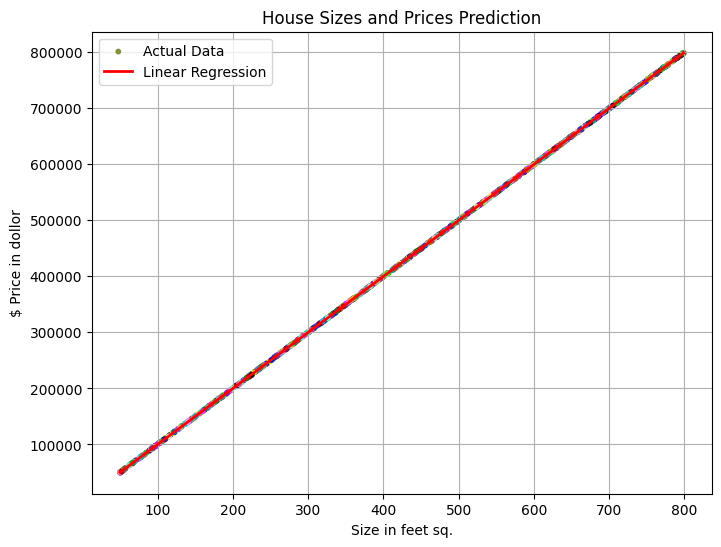

In [10]:
# SORTED DATA
i = np.argsort(X[:1000][:, 0])

# Sorted sizes
X_sorted = X[i]

# Sorted prices
y_hat = prediction[i]

colors = np.random.rand(len(X_sorted), 3)
# # ---------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

# Actual data
ax.scatter(X[:1000], y[:1000], s=10, c=colors, label='Actual Data')

# Model Prediction
ax.plot(X_sorted, y_hat, linewidth=2, label='Linear Regression', color='r')

# artist figure
ax.grid()
ax.set_xlabel('Size in feet sq.')
ax.set_ylabel('$ Price in dollor')
ax.set_title('House Sizes and Prices Prediction')

ax.legend()

plt.show()


In [11]:
# testing new, unseen data
size = int(input("Enter a House Size: "))

# predict
prediction = model.predict([[size]])

# Input size
print(f"Size: {size}")

# Predicted/Estimated output
print(f"Estimated Price: {round(prediction[0][0], 2)}")

# Expected price
expected = 1000 * size
print(f"Expected Price: {expected}")


Size: 890
Estimated Price: 890001.18
Expected Price: 890000
